<a href="https://colab.research.google.com/github/dhassan24/GO_Term_Prediction_ML/blob/main/DH_ML_GOPred_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Predicting Gene Ontology (GO) Terms from Sequence

Predicting phenotype and function directly from sequence has been a central goal in biology since the 1950s. In this project, I tackle a modern version of this challenge: can we predict gene function from sequence alone?

Objective is to build a model that predicts Gene Ontology (GO) terms—including:

Molecular Function (what the protein does)
Biological Process (what pathway it participates in)
Cellular Component (where it acts)

What Gene Ontology is:
https://geneontology.org/


In [1]:
## Donwload the data
## Train (sequences and terms; your X and Y)
!gdown 1dUMx8JktbTemOHLXfr3-oHkyr6fH9Cjh

!gdown 1wURic977SivfxGqQQZHxLg6kTDUqJ8DR

## Test your predicrtions here:
!gdown 1OencK6vcqFshlbXe6mfj4hMIIo9tkYLQ

Downloading...
From: https://drive.google.com/uc?id=1dUMx8JktbTemOHLXfr3-oHkyr6fH9Cjh
To: /content/GO_train_sequences.fasta
100% 53.3M/53.3M [00:00<00:00, 133MB/s]
Downloading...
From: https://drive.google.com/uc?id=1wURic977SivfxGqQQZHxLg6kTDUqJ8DR
To: /content/GO_train_terms.tsv
100% 10.8M/10.8M [00:00<00:00, 179MB/s]
Downloading...
From: https://drive.google.com/uc?id=1OencK6vcqFshlbXe6mfj4hMIIo9tkYLQ
To: /content/GO_test.fasta
100% 101M/101M [00:00<00:00, 116MB/s]  


In [4]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 36.4 MB/s eta 0:00:00


In [5]:
from Bio import SeqIO

Use BioPython to Load the GO Train and Test FASTA files

In [6]:
import pandas as pd
from Bio import SeqIO


def load_fasta_biopython(filepath: str) -> pd.DataFrame:
  records = [
      {
          "id": rec.id,
          "description": rec.description,
          "sequence": str(rec.seq).upper(),
          "seq_length": len(rec.seq),
      }
      for rec in SeqIO.parse(filepath, "fasta")
  ]

  return pd.DataFrame(records)

In [18]:
go_train = load_fasta_biopython("/content/GO_train_sequences.fasta")
go_train.head()

,id,description,sequence,seq_length
0,sp|A0A0C5B5G6|MOTSC_HUMAN,sp|A0A0C5B5G6|MOTSC_HUMAN Mitochondrial-derive...,MRWQEMGYIFYPRKLR,16
1,sp|A0JNW5|BLT3B_HUMAN,sp|A0JNW5|BLT3B_HUMAN Bridge-like lipid transf...,MAGIIKKQILKHLSRFTKNLSPDKINLSTLKGEGELKNLELDEEVL...,1464
2,sp|A0JP26|POTB3_HUMAN,sp|A0JP26|POTB3_HUMAN POTE ankyrin domain fami...,MVAEVCSMPAASAVKKPFDLRSKMGKWCHHRFPCCRGSGKSNMGTS...,581
3,sp|A0PK11|CLRN2_HUMAN,sp|A0PK11|CLRN2_HUMAN Clarin-2 OS=Homo sapiens...,MPGWFKKAWYGLASLLSFSSFILIIVALVVPHWLSGKILCQTGVDL...,232
4,sp|A1A4S6|RHG10_HUMAN,sp|A1A4S6|RHG10_HUMAN Rho GTPase-activating pr...,MGLQPLEFSDCYLDSPWFRERIRAHEAELERTNKFIKELIKDGKNL...,786


In [17]:
go_train.head()

,EntryID,description,sequence,seq_length
0,sp|A0A0C5B5G6|MOTSC_HUMAN,sp|A0A0C5B5G6|MOTSC_HUMAN Mitochondrial-derive...,MRWQEMGYIFYPRKLR,16
1,sp|A0JNW5|BLT3B_HUMAN,sp|A0JNW5|BLT3B_HUMAN Bridge-like lipid transf...,MAGIIKKQILKHLSRFTKNLSPDKINLSTLKGEGELKNLELDEEVL...,1464
2,sp|A0JP26|POTB3_HUMAN,sp|A0JP26|POTB3_HUMAN POTE ankyrin domain fami...,MVAEVCSMPAASAVKKPFDLRSKMGKWCHHRFPCCRGSGKSNMGTS...,581
3,sp|A0PK11|CLRN2_HUMAN,sp|A0PK11|CLRN2_HUMAN Clarin-2 OS=Homo sapiens...,MPGWFKKAWYGLASLLSFSSFILIIVALVVPHWLSGKILCQTGVDL...,232
4,sp|A1A4S6|RHG10_HUMAN,sp|A1A4S6|RHG10_HUMAN Rho GTPase-activating pr...,MGLQPLEFSDCYLDSPWFRERIRAHEAELERTNKFIKELIKDGKNL...,786


In [9]:
go_test = load_fasta_biopython("/content/GO_test.fasta")
go_test.head()

,id,description,sequence,seq_length
0,A0A0C5B5G6,A0A0C5B5G6 9606,MRWQEMGYIFYPRKLR,16
1,A0A1B0GTW7,A0A1B0GTW7 9606,MLLLLLLLLLLPPLVLRVAASRCLHDETQKSVSLLRPPFSQLPSKS...,788
2,A0JNW5,A0JNW5 9606,MAGIIKKQILKHLSRFTKNLSPDKINLSTLKGEGELKNLELDEEVL...,1464
3,A0JP26,A0JP26 9606,MVAEVCSMPAASAVKKPFDLRSKMGKWCHHRFPCCRGSGKSNMGTS...,581
4,A0PK11,A0PK11 9606,MPGWFKKAWYGLASLLSFSSFILIIVALVVPHWLSGKILCQTGVDL...,232


Load in the GO Train terms

In [13]:
go_train_terms = pd.read_csv("GO_train_terms.tsv", sep = "\t")
go_train_terms.head()

,EntryID,term,aspect
0,Q5W0B1,GO:0000785,C
1,Q5W0B1,GO:0004842,F
2,Q5W0B1,GO:0051865,P
3,Q5W0B1,GO:0006275,P
4,Q5W0B1,GO:0006513,P


# PROJECT WORKFLOW:



1.  Data loading, merging, exploratory analysis:


*  Join FASTA df with GO train terms on entry ID
* Term frequency by asepct (MF/BP/CC), sequence length disth, label co-occurrence


2.   Feature engineering


*   AA composition (20 features), dipeptide k-mers, physiochemical prop
*   ESM2 embeddings pre-trained on UniRed

3.   Label Encoding
*   Binary matrix (N proteins * M GO terms)
*   Spearate heads for MF/BP/CC aspects

4.  Baseline model
*   Multi-label RF/XGBoost on classical features
5.  Evaluation
*   F-max score, accuracy, micro/macro F1
6.  Test inference and submission:
*   Apply threshold --> EntryID, GO term, confidence score per row





**1.1: DATA MERGING + EXPLORATORY ANALYSIS**

In [28]:
#Xtract UniProt accession from pipe-delimited id column of go_train

go_train["EntryID"] = go_train["id"].str.split("|").str[1]

#Now merge with go_train_terms
merged_train_train = go_train.merge(go_train_terms, on = "EntryID", how = "inner")

In [29]:
merged_train_train.shape

(537027, 7)

In [30]:
merged_train_train.head()

,id,description,sequence,seq_length,EntryID,term,aspect
0,sp|A0A0C5B5G6|MOTSC_HUMAN,sp|A0A0C5B5G6|MOTSC_HUMAN Mitochondrial-derive...,MRWQEMGYIFYPRKLR,16,A0A0C5B5G6,GO:0001649,P
1,sp|A0A0C5B5G6|MOTSC_HUMAN,sp|A0A0C5B5G6|MOTSC_HUMAN Mitochondrial-derive...,MRWQEMGYIFYPRKLR,16,A0A0C5B5G6,GO:0033687,P
2,sp|A0A0C5B5G6|MOTSC_HUMAN,sp|A0A0C5B5G6|MOTSC_HUMAN Mitochondrial-derive...,MRWQEMGYIFYPRKLR,16,A0A0C5B5G6,GO:0005615,C
3,sp|A0A0C5B5G6|MOTSC_HUMAN,sp|A0A0C5B5G6|MOTSC_HUMAN Mitochondrial-derive...,MRWQEMGYIFYPRKLR,16,A0A0C5B5G6,GO:0005634,C
4,sp|A0A0C5B5G6|MOTSC_HUMAN,sp|A0A0C5B5G6|MOTSC_HUMAN Mitochondrial-derive...,MRWQEMGYIFYPRKLR,16,A0A0C5B5G6,GO:0005739,C


In [31]:
# How many proteins survived the join?
print(f"Proteins in FASTA:      {go_train['EntryID'].nunique()}")
print(f"Proteins in terms file: {go_train_terms['EntryID'].nunique()}")
print(f"Proteins after merge:   {merged_train_train['EntryID'].nunique()}")

# Terms per aspect
print(merged_train_train['aspect'].value_counts())

# Average GO terms per protein
print(merged_train_train.groupby('EntryID')['term'].count().describe())

Proteins in FASTA:      82404
Proteins in terms file: 82404
Proteins after merge:   82404
aspect
P    250805
C    157770
F    128452
Name: count, dtype: int64
count    82404.000000
mean         6.517002
std          7.965655
min          1.000000
25%          2.000000
50%          4.000000
75%          8.000000
max        233.000000
Name: term, dtype: float64


**1.2: EXPLORATORY ANALYSIS**

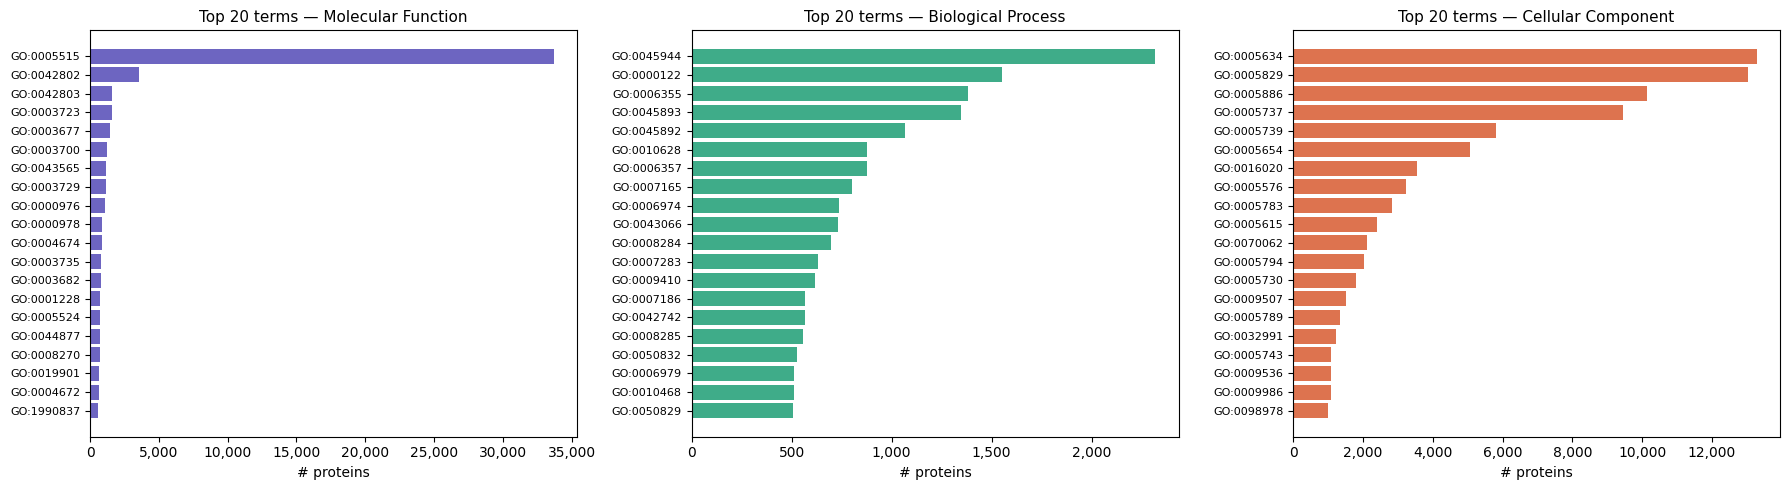

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from itertools import combinations
from collections import Counter

ASPECT_NAMES = {"F": "Molecular Function", "P": "Biological Process", "C": "Cellular Component"}
ASPECT_COLORS = {"F": "#534AB7", "P": "#1D9E75", "C": "#D85A30"}

# ── 1. Term frequency by aspect ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (asp, label) in zip(axes, ASPECT_NAMES.items()):
    counts = (merged_train_train[merged_train_train["aspect"] == asp]
              .groupby("term")["EntryID"].nunique()
              .sort_values(ascending=False)
              .head(20))
    ax.barh(counts.index[::-1], counts.values[::-1], color=ASPECT_COLORS[asp], alpha=0.85)
    ax.set_title(f"Top 20 terms — {label}", fontsize=11)
    ax.set_xlabel("# proteins")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.savefig("term_freq_by_aspect.png", dpi=150, bbox_inches="tight")
plt.show()


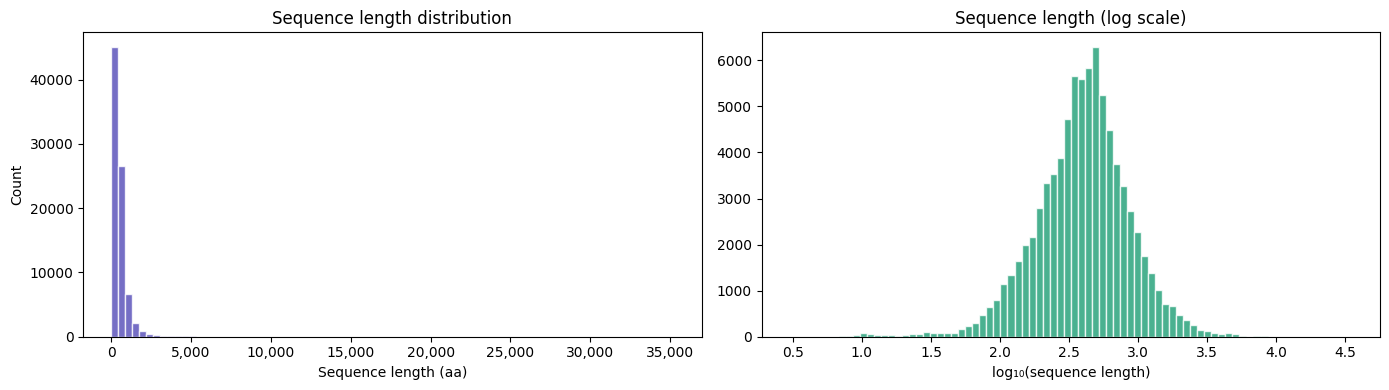

count    82404.0
mean       525.8
std        521.6
min          3.0
25%        250.0
50%        409.0
75%        630.0
max      35213.0
Name: seq_length, dtype: float64

Median: 409 aa
% > 1000 aa: 9.8%


In [34]:
# ── 2. Sequence length distribution ──────────────────────────────────────────
# One row per protein (deduplicated)
proteins = merged_train_train.drop_duplicates("EntryID")[["EntryID", "seq_length"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw distribution
axes[0].hist(proteins["seq_length"], bins=80, color="#534AB7", alpha=0.8, edgecolor="white", lw=0.4)
axes[0].set_xlabel("Sequence length (aa)")
axes[0].set_ylabel("Count")
axes[0].set_title("Sequence length distribution")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Log scale (better for long-tail proteins)
axes[1].hist(np.log10(proteins["seq_length"].clip(lower=1)), bins=80, color="#1D9E75", alpha=0.8,
             edgecolor="white", lw=0.4)
axes[1].set_xlabel("log₁₀(sequence length)")
axes[1].set_title("Sequence length (log scale)")

plt.tight_layout()
plt.savefig("seq_length_dist.png", dpi=150, bbox_inches="tight")
plt.show()

# Print summary stats
print(proteins["seq_length"].describe().round(1))
print(f"\nMedian: {proteins['seq_length'].median():.0f} aa")
print(f"% > 1000 aa: {(proteins['seq_length'] > 1000).mean()*100:.1f}%")


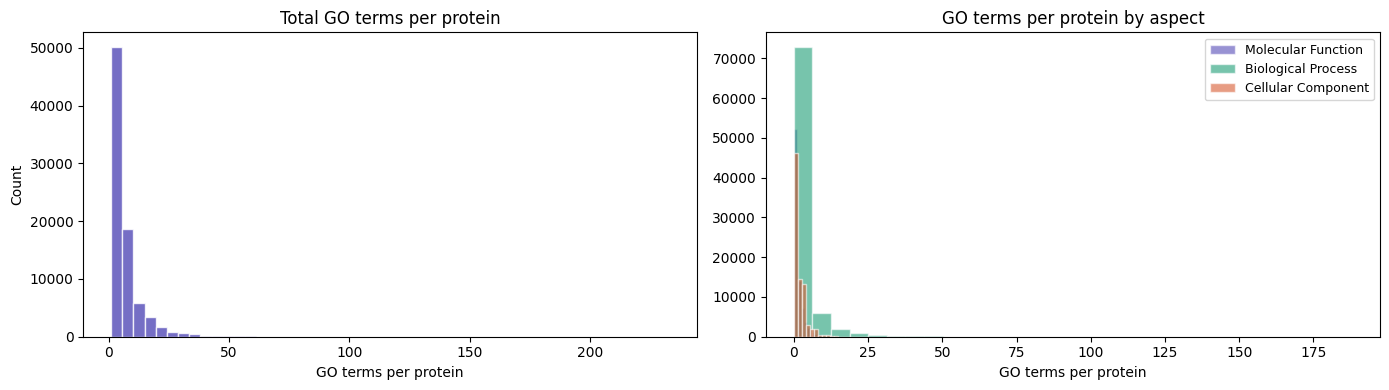

In [35]:
# ── 3. Labels per protein (how multi-label is the problem?) ──────────────────
terms_per_protein = merged_train_train.groupby("EntryID")["term"].count()
terms_per_aspect = (merged_train_train.groupby(["EntryID", "aspect"])["term"]
                    .count().unstack(fill_value=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(terms_per_protein, bins=50, color="#534AB7", alpha=0.8, edgecolor="white", lw=0.4)
axes[0].set_xlabel("GO terms per protein")
axes[0].set_ylabel("Count")
axes[0].set_title("Total GO terms per protein")

for asp, col in ASPECT_COLORS.items():
    if asp in terms_per_aspect.columns:
        axes[1].hist(terms_per_aspect[asp], bins=30, alpha=0.6,
                     label=ASPECT_NAMES[asp], color=col, edgecolor="white", lw=0.3)
axes[1].set_xlabel("GO terms per protein")
axes[1].set_title("GO terms per protein by aspect")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("labels_per_protein.png", dpi=150, bbox_inches="tight")
plt.show()


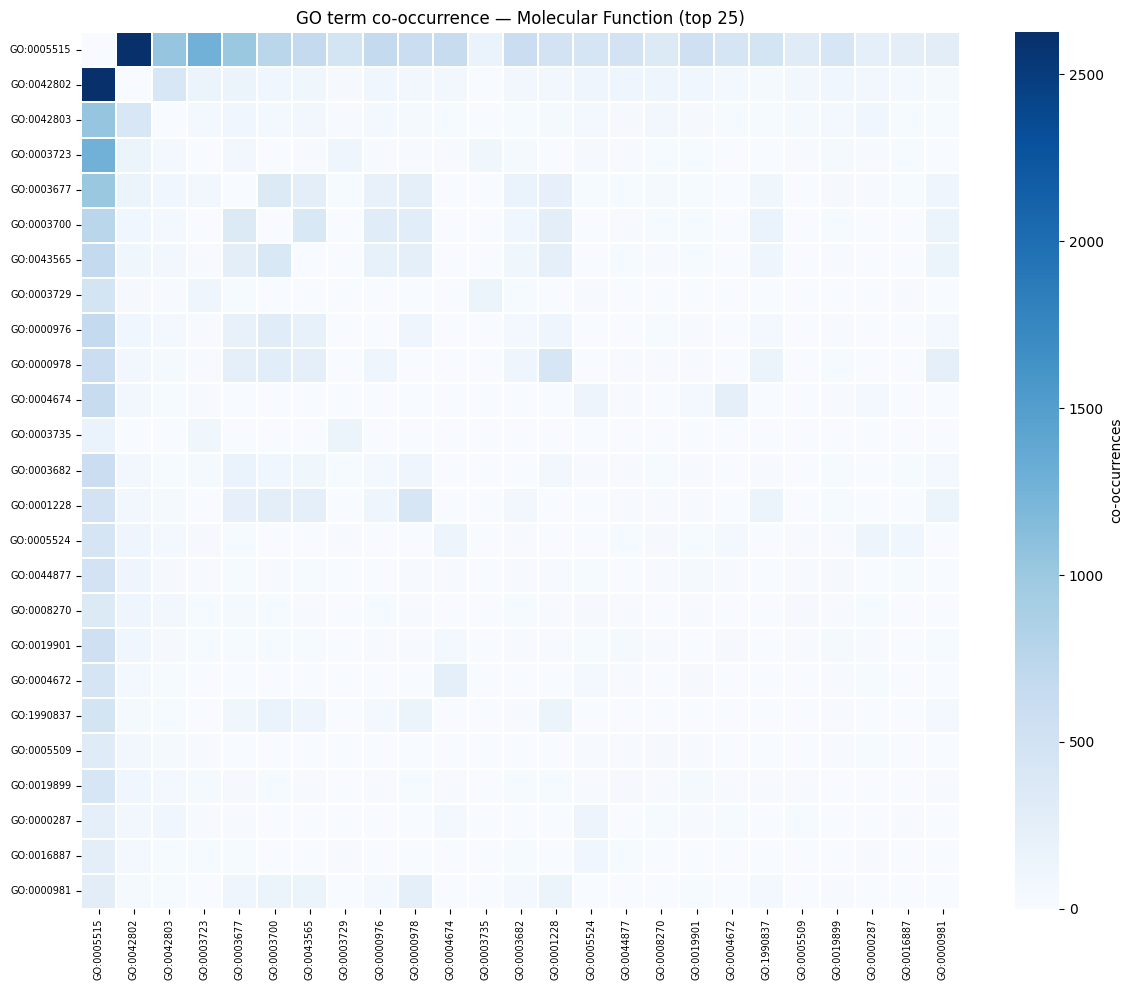

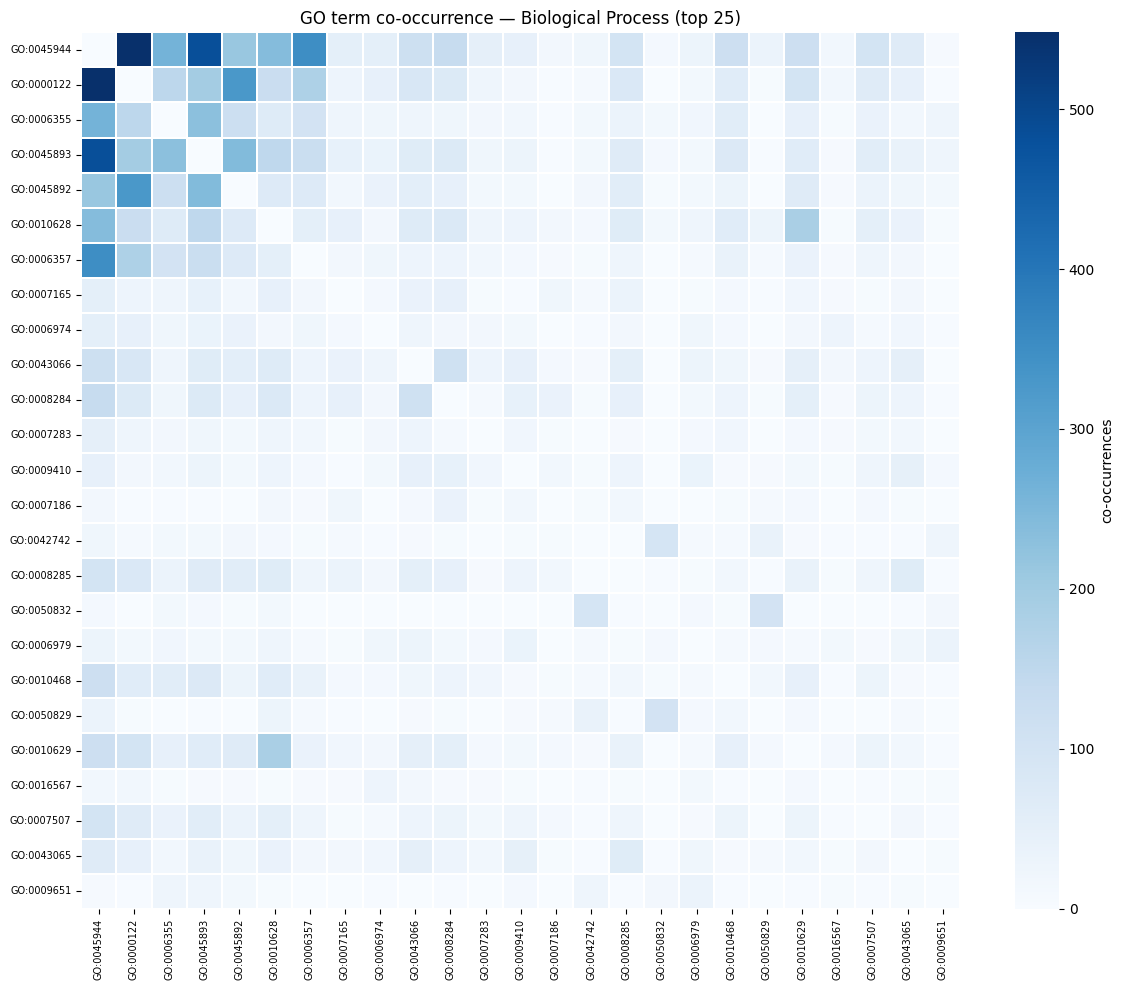

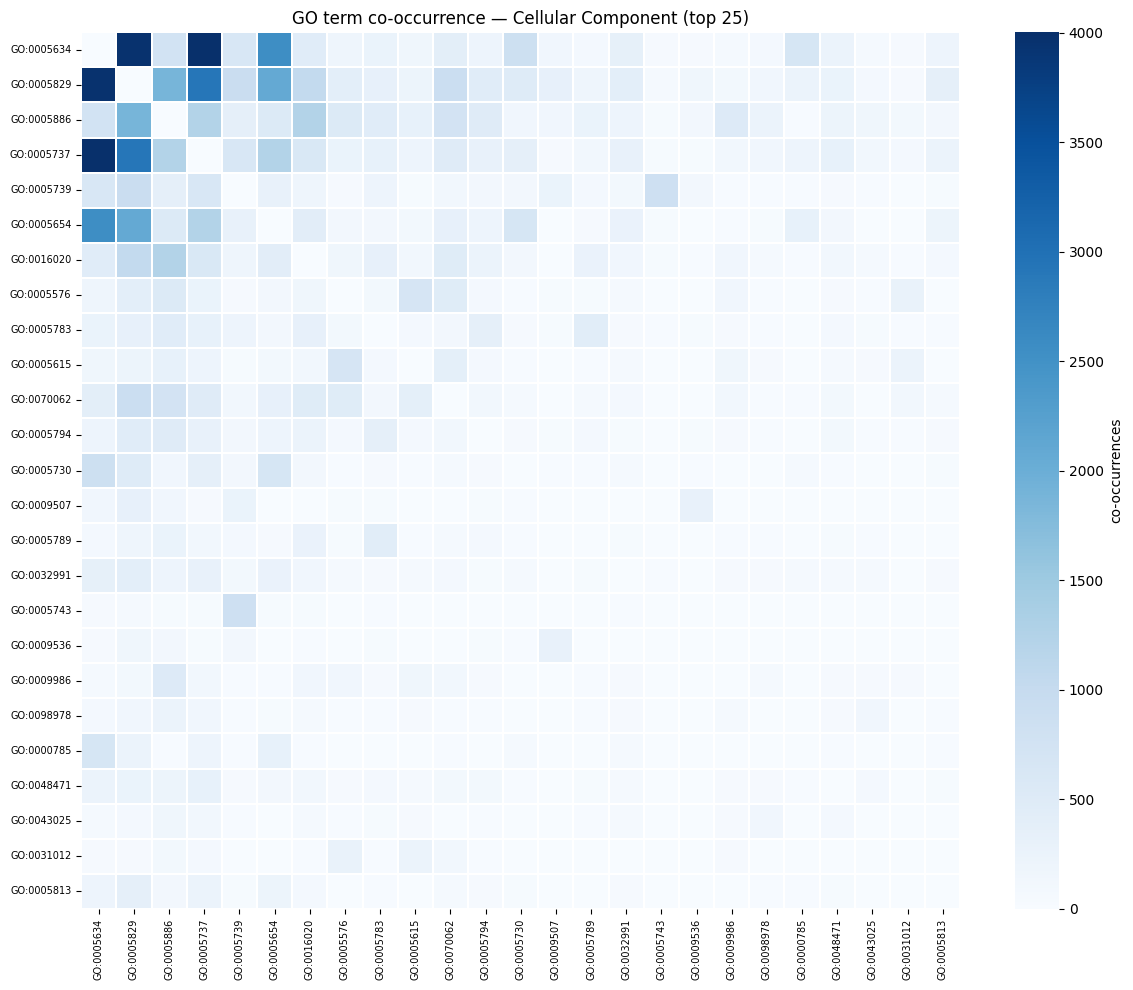


── Dataset summary ──
                    unique_terms  total_annotations  proteins_with_aspect
aspect                                                                   
Cellular Component          2651             157770                 60292
Molecular Function          6616             128452                 58001
Biological Process         16858             250805                 59958


In [36]:
# ── 4. Label co-occurrence (top N terms per aspect) ──────────────────────────
def plot_cooccurrence(df, aspect, top_n=30):
    aspect_df = df[df["aspect"] == aspect]
    top_terms = (aspect_df.groupby("term")["EntryID"].nunique()
                 .sort_values(ascending=False).head(top_n).index.tolist())

    # Build co-occurrence matrix
    protein_terms = (aspect_df[aspect_df["term"].isin(top_terms)]
                     .groupby("EntryID")["term"].apply(set))

    co_matrix = pd.DataFrame(0, index=top_terms, columns=top_terms)
    for terms in protein_terms:
        for t1, t2 in combinations(terms, 2):
            if t1 in co_matrix.index and t2 in co_matrix.columns:
                co_matrix.loc[t1, t2] += 1
                co_matrix.loc[t2, t1] += 1

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(co_matrix, ax=ax, cmap="Blues", xticklabels=True, yticklabels=True,
                linewidths=0.3, linecolor="white", cbar_kws={"label": "co-occurrences"})
    ax.set_title(f"GO term co-occurrence — {ASPECT_NAMES[aspect]} (top {top_n})", fontsize=12)
    ax.tick_params(axis="both", labelsize=7)
    plt.tight_layout()
    plt.savefig(f"cooccurrence_{aspect}.png", dpi=150, bbox_inches="tight")
    plt.show()

for asp in ["F", "P", "C"]:
    plot_cooccurrence(merged_train_train, asp, top_n=25)

In [38]:
# ── 5. Quick summary table ────────────────────────────────────────────────────
summary = (merged_train_train.groupby("aspect")
           .agg(unique_terms=("term", "nunique"),
                total_annotations=("term", "count"),
                proteins_with_aspect=("EntryID", "nunique"))
           .rename(index=ASPECT_NAMES))
print("\n── Dataset summary ──")
print(summary.to_string())


── Dataset summary ──
                    unique_terms  total_annotations  proteins_with_aspect
aspect                                                                   
Cellular Component          2651             157770                 60292
Molecular Function          6616             128452                 58001
Biological Process         16858             250805                 59958


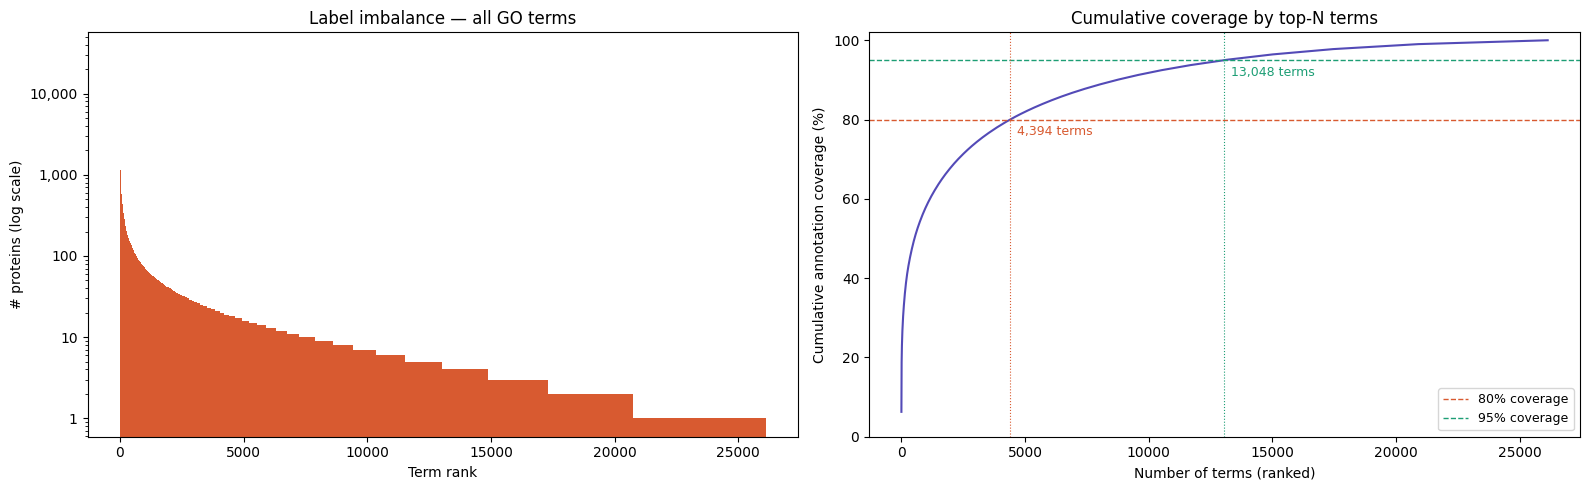

In [39]:
# ── 6. Label Imbalance ────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Count proteins per term (across all aspects)
term_counts = (merged_train.groupby("term")["EntryID"]
               .nunique()
               .sort_values(ascending=False)
               .reset_index(name="n_proteins"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: rank vs count (log y) ──────────────────────────────────────────────
axes[0].bar(range(len(term_counts)), term_counts["n_proteins"],
            color="#D85A30", width=1.0, linewidth=0)
axes[0].set_yscale("log")
axes[0].set_xlabel("Term rank")
axes[0].set_ylabel("# proteins (log scale)")
axes[0].set_title("Label imbalance — all GO terms")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{int(x):,}"))

# ── Right: cumulative coverage ────────────────────────────────────────────────
cumulative = term_counts["n_proteins"].cumsum() / term_counts["n_proteins"].sum() * 100
axes[1].plot(range(len(term_counts)), cumulative, color="#534AB7", lw=1.5)
axes[1].axhline(80, color="#D85A30", ls="--", lw=1, label="80% coverage")
axes[1].axhline(95, color="#1D9E75", ls="--", lw=1, label="95% coverage")

# Annotate where 80% and 95% are hit
for thresh, col in [(80, "#D85A30"), (95, "#1D9E75")]:
    idx = (cumulative >= thresh).idxmax()
    axes[1].axvline(idx, color=col, ls=":", lw=0.8)
    axes[1].text(idx + len(term_counts)*0.01, thresh - 4,
                 f"{idx:,} terms", fontsize=9, color=col)

axes[1].set_xlabel("Number of terms (ranked)")
axes[1].set_ylabel("Cumulative annotation coverage (%)")
axes[1].set_title("Cumulative coverage by top-N terms")
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 102)

plt.tight_layout()
plt.savefig("label_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

In [44]:
term_counts['n_proteins'].describe()

,n_proteins
count,26125.000000
mean,20.556057
std,268.143836
min,1.000000
25%,2.000000
50%,4.000000
75%,12.000000
max,33713.000000


In [45]:
# How many terms survive at each threshold?
for t in [5, 10, 25, 50, 100]:
    kept = (term_counts["n_proteins"] >= t).sum()
    coverage = term_counts.loc[term_counts["n_proteins"] >= t, "n_proteins"].sum()
    total_annot = term_counts["n_proteins"].sum()
    print(f"≥ {t:>3} proteins → {kept:>5,} terms  |  {coverage/total_annot*100:.1f}% annotation coverage")

≥   5 proteins → 13,039 terms  |  95.0% annotation coverage
≥  10 proteins → 7,873 terms  |  88.6% annotation coverage
≥  25 proteins → 3,374 terms  |  75.9% annotation coverage
≥  50 proteins → 1,585 terms  |  64.5% annotation coverage
≥ 100 proteins →   668 terms  |  52.8% annotation coverage


Filter out proteins that only appear less than 17 times per term:

In [49]:
MIN_PROTEINS = 17

keep_terms = term_counts.loc[term_counts["n_proteins"] >= MIN_PROTEINS, "term"]
merged_train = merged_train[merged_train["term"].isin(keep_terms)].copy()

# Per-aspect vocab sizes after filtering
print(merged_train.groupby("aspect")["term"].nunique())
# Expect roughly: C ~400, F ~800, P ~6,600

aspect
C     710
F     904
P    3307
Name: term, dtype: int64


In [50]:
merged_train.shape

(438868, 7)

**1.3: Filter out extremely long/short sequences or sequences that appear < 7 times**

In [59]:
# ── Per-protein sequence length (need one row per protein) ────────────────────
seq_lengths = (merged_train.drop_duplicates("EntryID")
               .set_index("EntryID")["seq_length"])

# Check what "extremely long" looks like in your data
print(merged_train.drop_duplicates("EntryID")["seq_length"].describe())
print(f"\n% sequences > 1024 aa: {(seq_lengths > 1024).mean()*100:.1f}%")
print(f"% sequences > 2000 aa: {(seq_lengths > 2000).mean()*100:.1f}%")
print(f"% sequences <    7 aa: {(seq_lengths < 7).mean()*100:.1f}%")

count    80009.000000
mean       527.102538
std        524.404076
min          3.000000
25%        250.000000
50%        410.000000
75%        634.000000
max      35213.000000
Name: seq_length, dtype: float64

% sequences > 1024 aa: 9.3%
% sequences > 2000 aa: 1.6%
% sequences <    7 aa: 0.0%


**1.4 Filter out BP terms with < 25 proteins**

In [69]:
BP_MIN = 25

#Term counts specifically in filtered merged_train

bp_term_counts = (merged_train[merged_train['aspect'] == 'P']
                  .groupby("term")["EntryID"].nunique())

bp_keep_terms = bp_term_counts[bp_term_counts >= BP_MIN].index

print(f"BP terms ≥ {BP_MIN} proteins:{len(bp_keep_terms):,}" f"(down from {len(bp_term_counts):,})")

BP terms ≥ 25 proteins:1,876(down from 3,307)


In [73]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import xgboost as xgb

In [74]:
# ── Modified label encoding for BP ───────────────────────────────────────────
mlbs, Y_dict = {}, {}

ASPECTS = {
    "F": "Molecular Function",
    "P": "Biological Process",
    "C": "Cellular Component"
}
# ── 1. Merge features with labels ─────────────────────────────────────────────
# feat_df has one row per protein; merged_train has one row per protein+term
# Group terms into a list per protein first
labels_grouped = (merged_train
                  .groupby("EntryID")["term"]
                  .apply(list)
                  .reset_index(name="terms"))

labels_grouped_aspect = (merged_train
                         .groupby(["EntryID", "aspect"])["term"]
                         .apply(list)
                         .unstack(fill_value=[])  # columns: C, F, P
                         .reset_index())

train_df = feat_df.merge(labels_grouped, on="EntryID")
print(f"Training df: {train_df.shape}")

for asp in ASPECTS:
    asp_data = merged_train[merged_train["aspect"] == asp].copy()

    # Apply secondary filter only for BP
    if asp == "P":
        asp_data = asp_data[asp_data["term"].isin(bp_keep_terms)]

    asp_labels = asp_data.groupby("EntryID")["term"].apply(list)

    asp_series = train_df["EntryID"].map(asp_labels).apply(
        lambda x: x if isinstance(x, list) else []
    )
    mlb = MultiLabelBinarizer()
    Y_dict[asp] = mlb.fit_transform(asp_series)
    mlbs[asp] = mlb
    print(f"  {asp}: {Y_dict[asp].shape[1]:,} labels")

Training df: (72201, 431)
  F: 904 labels
  P: 1,876 labels
  C: 710 labels


In [60]:
MIN_LEN = 20      # your stated minimum
MAX_LEN = 1024   # ESM-2 hard limit — natural cutoff

valid_proteins = seq_lengths[
    (seq_lengths >= MIN_LEN) & (seq_lengths <= MAX_LEN)
].index

merged_train = merged_train[merged_train["EntryID"].isin(valid_proteins)].copy()

print(f"Proteins before: {seq_lengths.shape[0]:,}")
print(f"Proteins after:  {merged_train['EntryID'].nunique():,}")
print(f"Rows before:     438,868")
print(f"Rows after:      {len(merged_train):,}")

Proteins before: 80,009
Proteins after:  72,201
Rows before:     438,868
Rows after:      380,784


In [61]:
merged_train['sequence'].describe()

,sequence
count,380784
unique,71067
top,MADQLTEEQIAEFKEAFSLFDKDGDGTITTKELGTVMRSLGQNPTE...
freq,183


In [62]:
merged_train['term'].describe()

,term
count,380784
unique,4921
top,GO:0005515
freq,29788


# **SECTION 2: FEATURE ENGINEERING**

Starting with just classical features first

In [63]:
import numpy as np
import pandas as pd
from collections import Counter

# ── Constants ─────────────────────────────────────────────────────────────────
AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

# Kyte-Doolittle hydrophobicity, charge at pH7, molecular weight
HYDROPHOBICITY = {
    "A": 1.8,  "R": -4.5, "N": -3.5, "D": -3.5, "C": 2.5,
    "Q": -3.5, "E": -3.5, "G": -0.4, "H": -3.2, "I": 4.5,
    "L": 3.8,  "K": -3.9, "M": 1.9,  "F": 2.8,  "P": -1.6,
    "S": -0.8, "T": -0.7, "W": -0.9, "Y": -1.3, "V": 4.2,
}
CHARGE = {
    "R": 1, "K": 1, "H": 0.1,
    "D": -1, "E": -1,
    **{aa: 0 for aa in "ACFGILMNPQSTVWY"},
}
MW = {
    "A": 89,  "R": 174, "N": 132, "D": 133, "C": 121,
    "Q": 146, "E": 147, "G": 75,  "H": 155, "I": 131,
    "L": 131, "K": 146, "M": 149, "F": 165, "P": 115,
    "S": 105, "T": 119, "W": 204, "Y": 181, "V": 117,
}

# ── 1. Amino acid composition (20 features) ───────────────────────────────────
def aa_composition(seq):
    seq = seq.upper()
    n = max(len(seq), 1)
    return {f"aa_{aa}": seq.count(aa) / n for aa in AMINO_ACIDS}

# ── 2. Dipeptide composition (400 features) ───────────────────────────────────
def dipeptide_composition(seq):
    seq = seq.upper()
    n = max(len(seq) - 1, 1)
    dipeptides = [seq[i:i+2] for i in range(len(seq) - 1)]
    counts = Counter(dipeptides)
    return {
        f"dp_{a}{b}": counts.get(f"{a}{b}", 0) / n
        for a in AMINO_ACIDS for b in AMINO_ACIDS
    }

# ── 3. Physicochemical properties (9 features) ────────────────────────────────
def physicochemical(seq):
    seq = seq.upper()
    valid = [aa for aa in seq if aa in AMINO_ACIDS]
    n = max(len(valid), 1)

    hydro = [HYDROPHOBICITY.get(aa, 0) for aa in valid]
    charge_vals = [CHARGE.get(aa, 0) for aa in valid]

    return {
        "phys_length":        len(seq),
        "phys_hydro_mean":    np.mean(hydro),
        "phys_hydro_std":     np.std(hydro),
        "phys_charge_total":  sum(charge_vals),
        "phys_charge_mean":   np.mean(charge_vals),
        "phys_mw":            sum(MW.get(aa, 0) for aa in valid),
        "phys_aromaticity":   sum(seq.count(aa) for aa in "FWY") / n,
        "phys_instability":   _instability_index(seq),
        "phys_gravy":         sum(HYDROPHOBICITY.get(aa, 0) for aa in valid) / n,
    }

def _instability_index(seq):
    # Guruprasad et al. 1990 — dipeptide instability weights
    DIWV = {
        "WW": 1.0, "WC": 1.0, "WD": 1.0, "WE": 1.0, "WM": 24.68,
        "CK": 1.0, "CN": 1.0, "CQ": 29.62, "CF": 1.0,
        "GW": 13.34, "GN": 1.0, "GQ": 1.0, "GE": 1.0,
        "HH": 1.0, "HM": 1.0, "HN": 1.0, "Hq": 1.0,
    }
    if len(seq) < 2:
        return 0.0
    score = sum(DIWV.get(seq[i:i+2], 1.0) for i in range(len(seq) - 2))
    return (10.0 / len(seq)) * score

# ── 4. Combine all classical features ─────────────────────────────────────────
def extract_classical_features(seq):
    feats = {}
    feats.update(aa_composition(seq))
    feats.update(dipeptide_composition(seq))
    feats.update(physicochemical(seq))
    return feats


In [64]:
# ── 5. Apply to your dataframe ────────────────────────────────────────────────
# Get one row per protein
proteins_df = merged_train.drop_duplicates("EntryID")[["EntryID", "sequence"]].reset_index(drop=True)

print(f"Extracting features for {len(proteins_df):,} proteins...")
feat_rows = [extract_classical_features(seq) for seq in proteins_df["sequence"]]
feat_df = pd.DataFrame(feat_rows)
feat_df.insert(0, "EntryID", proteins_df["EntryID"])

print(f"Feature matrix: {feat_df.shape}")  # (n_proteins, 429)
print(feat_df.iloc[:, :5].head())

Extracting features for 72,201 proteins...
Feature matrix: (72201, 430)
  EntryID      aa_A      aa_C      aa_D      aa_E
0  A0JP26  0.053356  0.037866  0.063683  0.092943
1  A0PK11  0.107759  0.021552  0.021552  0.051724
2  A1A4S6  0.058524  0.013995  0.047074  0.090331
3  A1A519  0.030303  0.030303  0.030303  0.148485
4  A1L190  0.056818  0.011364  0.090909  0.147727


In [65]:
feat_df.head()

,EntryID,aa_A,aa_C,aa_D,aa_E,aa_F,aa_G,aa_H,aa_I,aa_K,...,dp_YY,phys_length,phys_hydro_mean,phys_hydro_std,phys_charge_total,phys_charge_mean,phys_mw,phys_aromaticity,phys_instability,phys_gravy
0,A0JP26,0.053356,0.037866,0.063683,0.092943,0.015491,0.056799,0.034423,0.036145,0.092943,...,0.000000,581,-0.775387,3.059642,-6.0,-0.010327,76076,0.041308,10.950775,-0.775387
1,A0PK11,0.107759,0.021552,0.021552,0.051724,0.064655,0.073276,0.021552,0.081897,0.043103,...,0.004329,232,0.757759,3.042689,-0.5,-0.002155,29574,0.112069,11.679310,0.757759
2,A1A4S6,0.058524,0.013995,0.047074,0.090331,0.053435,0.049618,0.026718,0.045802,0.077608,...,0.000000,786,-0.585623,3.037427,-0.9,-0.001145,103403,0.083969,10.131552,-0.585623
3,A1A519,0.030303,0.030303,0.030303,0.148485,0.018182,0.066667,0.027273,0.015152,0.054545,...,0.003040,330,-1.018485,2.789427,-19.1,-0.057879,43039,0.045455,10.313333,-1.018485
4,A1L190,0.056818,0.011364,0.090909,0.147727,0.011364,0.000000,0.011364,0.011364,0.079545,...,0.000000,88,-0.867045,3.100100,-8.9,-0.101136,12155,0.056818,12.463636,-0.867045
